In [1]:
import gymnasium as gym
import humanoid_bench
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import xgboost as xgb
import imageio

In [2]:
env = gym.make('h1hand-crawl-v0')
# env = gym.make('h1hand-stand-v0')
print(env.action_space)
print(env.observation_space)
print(env.reward_range)

Box(-1.0, 1.0, (61,), float32)
Box(-inf, inf, (151,), float64)
(-inf, inf)


In [24]:
fn = f"/Users/yuxinbai/Desktop/projects_repo/humanoid-bench/results/plc/humanoid_envseed519_518_warmup800_online300_lookahea5_greedy4_gamma099_wo_normalized.npz"
data = np.load(fn)
ACTIONS_arr = data["ACTIONS_arr"]
REWARDS_arr_trained  = data["REWARDS_arr"]
print(ACTIONS_arr)

[[-0.56872237  0.84895056 -0.11487757 ...  0.85495406  0.66819584
  -0.4944021 ]
 [-0.3097091  -0.5519983   0.16070977 ...  0.04386437  0.42987925
   0.5624089 ]
 [ 0.5101003  -0.64606684  0.6122199  ...  0.61543214  0.7968269
  -0.14030467]
 ...
 [ 0.7910101   0.19684893 -0.13607974 ... -0.51300186 -0.92166895
   0.36578497]
 [ 0.9815306  -0.7029962   0.5900759  ...  0.74279696 -0.8328079
   0.20078644]
 [ 0.2499878   0.16805087 -0.6508908  ...  0.8890679   0.26747707
   0.5795636 ]]


In [25]:
fn = f"/Users/yuxinbai/Desktop/projects_repo/humanoid-bench/results/plc/humanoid_envseed519_518_warmup800_online300_lookahea5_random4_gamma099_wo_normalized.npz"
data = np.load(fn)
ACTIONS_arr = data["ACTIONS_arr"]
REWARDS_arr_trained  = data["REWARDS_arr"]
print(ACTIONS_arr)

[[-0.56872237  0.84895056 -0.11487757 ...  0.85495406  0.66819584
  -0.4944021 ]
 [-0.3097091  -0.5519983   0.16070977 ...  0.04386437  0.42987925
   0.5624089 ]
 [ 0.5101003  -0.64606684  0.6122199  ...  0.61543214  0.7968269
  -0.14030467]
 ...
 [-0.9402809  -0.05976875  0.16253068 ...  0.41853437  0.63460594
  -0.11977122]
 [-0.1575639  -0.7239457  -0.54976547 ...  0.25696963 -0.05309033
   0.13409032]
 [-0.1575639  -0.7239457  -0.54976547 ...  0.25696963 -0.05309033
   0.13409032]]


[[-0.56872237  0.84895056 -0.11487757 ...  0.85495406  0.66819584
  -0.4944021 ]
 [-0.3097091  -0.5519983   0.16070977 ...  0.04386437  0.42987925
   0.5624089 ]
 [ 0.5101003  -0.64606684  0.6122199  ...  0.61543214  0.7968269
  -0.14030467]
 ...
 [-0.9402809  -0.05976875  0.16253068 ...  0.41853437  0.63460594
  -0.11977122]
 [-0.1575639  -0.7239457  -0.54976547 ...  0.25696963 -0.05309033
   0.13409032]
 [-0.1575639  -0.7239457  -0.54976547 ...  0.25696963 -0.05309033
   0.13409032]]
(1100, 61)
(1100, 151)
[[-0.56872237  0.84895056 -0.11487757 ...  0.85495406  0.66819584
  -0.4944021 ]
 [-0.3097091  -0.5519983   0.16070977 ...  0.04386437  0.42987925
   0.5624089 ]
 [ 0.5101003  -0.64606684  0.6122199  ...  0.61543214  0.7968269
  -0.14030467]
 ...
 [ 0.7910101   0.19684893 -0.13607974 ... -0.51300186 -0.92166895
   0.36578497]
 [ 0.9815306  -0.7029962   0.5900759  ...  0.74279696 -0.8328079
   0.20078644]
 [ 0.2499878   0.16805087 -0.6508908  ...  0.8890679   0.26747707
   0.5795636

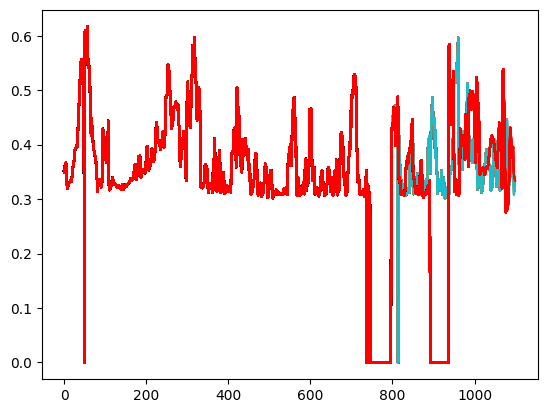

In [13]:
max_step = 1100
iters = 1
OBS = []
ACTIONS = []
REWARDS = []
TIMES = []
fn = f"/Users/yuxinbai/Desktop/projects_repo/humanoid-bench/results/plc/humanoid_envseed519_518_warmup800_online300_lookahea5_random4_gamma099_wo_normalized.npz"
data = np.load(fn)
ACTIONS_arr = data["ACTIONS_arr"]
REWARDS_random  = data["REWARDS_arr"]
print(ACTIONS_arr)


for ite in range(iters):
    observation, info = env.reset(seed=519)
    env.action_space.seed(518)
    actions = []
    observations = []
    rewards = []
    times = []
    for step in range(1,max_step+1):
        if step <= 800:
            action = env.action_space.sample()
        else:
            action = ACTIONS_arr[step-800]
        # action = np.zeros(env.action_space.shape, dtype=np.float32) ## test with action = 0
        observation, reward, terminated, truncated, info = env.step(action)
        # done = terminated or truncated
        # if done:
        #     # print(step)
        #     break
        actions.append(action)
        observations.append(observation)
        rewards.append(reward)
        times.append(step)
        plt.plot(range(step),rewards)

    ACTIONS.append(actions)
    OBS.append(observations)
    REWARDS.append(np.array(rewards).reshape(-1,1))
    TIMES.append(np.array(times).reshape(-1,1))
ACTIONS_arr =  np.vstack(ACTIONS)
OBS_arr =  np.vstack(OBS)
REWARDS_arr =  np.vstack(REWARDS)
TIMES_arr =  np.vstack(TIMES)
print(ACTIONS_arr.shape)
print(OBS_arr.shape)


fn = f"/Users/yuxinbai/Desktop/projects_repo/humanoid-bench/results/plc/humanoid_envseed519_518_warmup800_online300_lookahea5_greedy4_gamma099_wo_normalized.npz"
data2 = np.load(fn)
ACTIONS_arr = data2["ACTIONS_arr"]
REWARDS_greedy  = data2["REWARDS_arr"]
print(ACTIONS_arr)


max_step = 1100
iters = 1
OBS = []
ACTIONS = []
REWARDS = []
TIMES = []

for ite in range(iters):
    observation, info = env.reset(seed=519)
    env.action_space.seed(518)
    actions = []
    observations = []
    rewards = []
    times = []
    for step in range(1,max_step+1):
        if step <= 800:
            action = env.action_space.sample()
        else:
            # print(step)
            action = ACTIONS_arr[step-1]
        # action = np.zeros(env.action_space.shape, dtype=np.float32) ## test with action = 0
        observation, reward, terminated, truncated, info = env.step(action)
        # done = terminated or truncated
        # if done:
        #     # print(step)
        #     break
        actions.append(action)
        observations.append(observation)
        rewards.append(reward)
        times.append(step)
        plt.plot(range(step),rewards,'red')

    # ACTIONS.append(actions)
    OBS.append(observations)
    REWARDS.append(np.array(rewards).reshape(-1,1))
    TIMES.append(np.array(times).reshape(-1,1))

# ACTIONS_arr =  np.vstack(ACTIONS)
OBS_arr =  np.vstack(OBS)
REWARDS_arr =  np.vstack(REWARDS)
TIMES_arr =  np.vstack(TIMES)
print(ACTIONS_arr.shape)
print(OBS_arr.shape)

[[-0.56872237  0.84895056 -0.11487757 ...  0.85495406  0.66819584
  -0.4944021 ]
 [-0.3097091  -0.5519983   0.16070977 ...  0.04386437  0.42987925
   0.5624089 ]
 [ 0.5101003  -0.64606684  0.6122199  ...  0.61543214  0.7968269
  -0.14030467]
 ...
 [ 0.7910101   0.19684893 -0.13607974 ... -0.51300186 -0.92166895
   0.36578497]
 [ 0.9815306  -0.7029962   0.5900759  ...  0.74279696 -0.8328079
   0.20078644]
 [ 0.2499878   0.16805087 -0.6508908  ...  0.8890679   0.26747707
   0.5795636 ]]
(1100, 61)
(1100, 151)


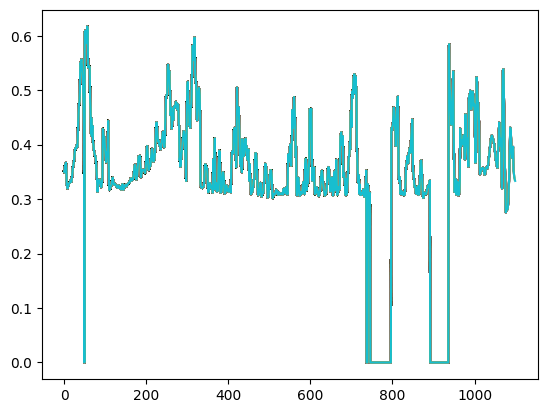

In [ ]:
REWARDS_greedy

In [15]:
T = 1100
plt.plot(np.arange(T-500,T),REWARD_random[T-500:T], c = 'orange',alpha = 0.5,label = 'online policy update (uniformly select) depth = 5, n_action = 4')
# plt.plot(np.arange(T-500,T-300),REWARD_random[T-500:T-300], c = 'red',alpha = 0.5)
plt.plot(np.arange(T-500,T),REWARD_greedy[T-500:T], c = 'red',alpha = 0.5,label = 'online policy update (greedy select, n_action = 30 ) depth = 5, k_action = 4')

NameError: name 'REWARD_random' is not defined